# Data Cleaning + Pre-Groundtype Modeling

- Imports/settings are consolidated at the top
- Run cells top-to-bottom after restarting the kernel.

## 0. setup

contains all imports + functions

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import time
import plotly.express as px
from plotly import graph_objs as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode, iplot
import plotly.io as pio
import plotly.graph_objects as go
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

In [3]:
def drop_columns(df, columns):
    df = df.drop(columns= columns)
    return df

In [4]:
def to_milliseconds(df): 
    df["date_time"] = pd.to_datetime(df['timestamp'], unit='ms')
    df["time_elapsed"] = (df['date_time'] - df['date_time'].iloc[0]).dt.total_seconds() 
    return df

## 1. load in all data

contains all data loads & creation of data frames

In [5]:
# asphalt 
asphalt_r_df = pd.read_csv("data/catherine/asphalt_primary.csv")
asphalt_l_df = pd.read_csv("data/catherine/asphalt_secondary.csv")
# brick
brick_r_df = pd.read_csv("data/catherine/brick_primary.csv")
brick_l_df = pd.read_csv("data/catherine/brick_secondary.csv")
# grass
grass_r_df = pd.read_csv("data/catherine/grass_primary.csv")
grass_l_df = pd.read_csv("data/catherine/grass_secondary.csv")

# multi data 
multi_r_df = pd.read_csv("data/catherine/multi_recordV2Primary.csv")
multi_l_df = pd.read_csv("data/catherine/multi_recordV2Secondary.csv") 

In [6]:
# add ground types
asphalt_r_df['ground_type'] = "asphalt"
asphalt_l_df['ground_type'] = "asphalt"
brick_r_df['ground_type'] = "brick"
brick_l_df['ground_type'] = "brick"
grass_r_df['ground_type'] = "grass"
grass_l_df['ground_type'] = "grass"

## 2. cleaning and pre-processing 

In [7]:
# set conditions of the data set 
conditions = ["Grass", "Asphalt", "Brick", "Multi"]
data_by_condition = {
    "Grass":   (grass_r_df, grass_l_df),
    "Asphalt": (asphalt_r_df, asphalt_l_df),
    "Brick":   (brick_r_df, brick_l_df),
    "Multi": (multi_r_df, multi_l_df)
}

In [8]:
# set conditons for sensor positions
heel     = ['pressure_10', 'pressure_11', 'pressure_08']
midfoot  = ['pressure_03', 'pressure_07']
forefoot = ['pressure_02', 'pressure_05', 'pressure_04', 'pressure_06', 'pressure_09']
toes     = ['pressure_01', 'pressure_12']

sensor_cols = [*toes, *forefoot, *midfoot, *heel] 
sensor_cols2 = [*heel, *midfoot, *forefoot, *toes] 

In [9]:
# drop uneeded columns
dfs = [asphalt_r_df, asphalt_l_df, brick_r_df, brick_l_df, grass_r_df, grass_l_df]

remove_cols = ['magn_x', 'magn_y', 'magn_z', 'corrupt']

for i in range(len(dfs)):
    dfs[i] = dfs[i].drop(columns=remove_cols, errors='ignore')

asphalt_r_df, asphalt_l_df, brick_r_df, brick_l_df, grass_r_df, grass_l_df = dfs

In [10]:
# convert to milliseconds  
dfs = [asphalt_r_df, asphalt_l_df, brick_r_df, brick_l_df, grass_r_df, grass_l_df]

dfs = [to_milliseconds(df) for df in dfs]

asphalt_r_df, asphalt_l_df, brick_r_df, brick_l_df, grass_r_df, grass_l_df = dfs

In [11]:
# save csv as new csv 
asphalt_r_df.to_csv("data_cleaned/asphalt_r_clean.csv", index=False)
asphalt_l_df.to_csv("data_cleaned/asphalt_l_clean.csv", index=False)

brick_r_df.to_csv("data_cleaned/brick_r_clean.csv", index=False)
brick_l_df.to_csv("data_cleaned/brick_l_clean.csv", index=False)

grass_r_df.to_csv("data_cleaned/grass_r_clean.csv", index=False)
grass_l_df.to_csv("data_cleaned/grass_l_clean.csv", index=False)

print("Saved all CSV files.")

Saved all CSV files.


In [12]:
# reload in new cleaned data 

asphalt_r_df = pd.read_csv("data_cleaned/asphalt_r_clean.csv")
asphalt_l_df = pd.read_csv("data_cleaned/asphalt_l_clean.csv")

brick_r_df = pd.read_csv("data_cleaned/brick_r_clean.csv")
brick_l_df = pd.read_csv("data_cleaned/brick_l_clean.csv")

grass_r_df = pd.read_csv("data_cleaned/grass_r_clean.csv")
grass_l_df = pd.read_csv("data_cleaned/grass_l_clean.csv")

print("Loaded all CSV files.")

Loaded all CSV files.


In [13]:
# merge data frames

asphalt_df = pd.concat([asphalt_r_df, asphalt_l_df], ignore_index=True)
brick_df   = pd.concat([brick_r_df, brick_l_df], ignore_index=True)
grass_df   = pd.concat([grass_r_df, grass_l_df], ignore_index=True)
multi_df   = pd.concat([multi_r_df, multi_l_df], ignore_index=True)

all_df = pd.concat([asphalt_r_df, asphalt_l_df, brick_r_df, brick_l_df, grass_r_df, grass_l_df, multi_r_df, multi_l_df], ignore_index=True)

In [14]:
all_df.to_csv("data_cleaned/all_data.csv", index=False)

## data transformation

In [20]:
df = pd.read_csv("data_cleaned/all_data.csv", low_memory=False)

# drop empty cols
drop_cols = [c for c in ["magn_x", "magn_y", "magn_z", "corrupt"] if c in df.columns]
df = df.drop(columns=drop_cols)

df = df.sort_values(["ground_type", "sole_id", "timestamp"]).reset_index(drop=True)

pressure_cols = [c for c in df.columns if c.startswith("pressure_")]
imu_cols = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]


In [21]:
def segment_steps(
    g: pd.DataFrame,
    smooth_window: int = 5,
    min_len: int = 8,
    max_len: int = 200,
    gap_tolerance: int = 1,
) -> pd.DataFrame:
    """
    Segment steps using total pressure thresholding inside one (ground_type, sole_id) group.
    Returns step-level features.
    """
    g = g.sort_values("timestamp").reset_index(drop=True).copy()

    total = g[pressure_cols].sum(axis=1).astype(float)
    smooth = total.rolling(smooth_window, center=True, min_periods=1).mean()

    # adaptive threshold per group
    med = float(np.nanmedian(smooth))
    p95 = float(np.nanpercentile(smooth, 95))
    thr = med + 0.25 * (p95 - med)

    above = smooth > thr

    # label contiguous "above threshold" runs as steps (with small gap tolerance)
    step_id = np.full(len(g), -1, dtype=int)
    current = -1
    i = 0

    while i < len(g):
        if above.iloc[i]:
            current += 1
            step_id[i] = current

            j = i + 1
            gap = 0
            while j < len(g):
                if above.iloc[j]:
                    step_id[j] = current
                    gap = 0
                else:
                    gap += 1
                    if gap > gap_tolerance:
                        break
                    step_id[j] = current
                j += 1
            i = j
        else:
            i += 1

    g["step_id_raw"] = step_id
    g = g[g["step_id_raw"] >= 0].copy()
    if g.empty:
        return pd.DataFrame()

    feats = []
    for sid, seg in g.groupby("step_id_raw", sort=True):
        n = len(seg)
        if n < min_len or n > max_len:
            continue

        duration_s = (seg["timestamp"].iloc[-1] - seg["timestamp"].iloc[0]) / 1000.0
        total_series = seg[pressure_cols].sum(axis=1)

        row = {
            "ground_type": seg["ground_type"].iloc[0],
            "sole_id": int(seg["sole_id"].iloc[0]),
            "n_samples": n,
            "duration_s": duration_s,
            "total_pressure_mean": float(total_series.mean()),
            "total_pressure_max": float(total_series.max()),
            "total_pressure_std": float(total_series.std(ddof=0)),
            "total_pressure_auc": float(total_series.sum()),  # proportional to impulse
        }

        # pressure features
        for c in pressure_cols:
            row[f"{c}_mean"] = float(seg[c].mean())
            row[f"{c}_max"]  = float(seg[c].max())
            row[f"{c}_std"]  = float(seg[c].std(ddof=0))

        # IMU features
        for c in imu_cols:
            if c in seg.columns:
                row[f"{c}_mean"] = float(seg[c].mean())
                row[f"{c}_max"]  = float(seg[c].max())
                row[f"{c}_std"]  = float(seg[c].std(ddof=0))

        feats.append(row)

    return pd.DataFrame(feats)


In [22]:
# build steps 
step_parts = []
for (gt, sole), g in df.groupby(["ground_type", "sole_id"], sort=False):
    step_parts.append(segment_steps(g))

step_df = pd.concat(step_parts, ignore_index=True)
print("Step-level shape:", step_df.shape)
print(step_df["ground_type"].value_counts())

# Save step-level CSV
step_df.to_csv("step_level_data.csv", index=False)

Step-level shape: (348, 62)
ground_type
asphalt    123
grass      119
brick      106
Name: count, dtype: int64


In [44]:
step_df

,ground_type,sole_id,n_samples,duration_s,total_pressure_mean,total_pressure_max,total_pressure_std,total_pressure_auc,pressure_01_mean,pressure_01_max,...,accel_z_std,gyro_x_mean,gyro_x_max,gyro_x_std,gyro_y_mean,gyro_y_max,gyro_y_std,gyro_z_mean,gyro_z_max,gyro_z_std
0,asphalt,1,11,0.160,4623.272727,4835.0,174.098766,50856.0,561.181818,612.0,...,1850.821359,5.815431e+05,2046398.0,5.386342e+05,23545.636364,265115.0,171700.038460,132390.545455,237015.0,64528.696409
1,asphalt,1,9,0.128,4822.333333,5946.0,668.241972,43401.0,469.666667,586.0,...,7297.892618,-3.511660e+06,766025.0,3.185523e+06,325251.444444,1822821.0,962382.253565,-249097.111111,87964.0,313544.979562
2,asphalt,1,44,0.688,4796.840909,5339.0,288.311696,211061.0,538.863636,631.0,...,1115.942192,7.838229e+05,4190535.0,9.463903e+05,-33375.068182,1112996.0,225968.503996,107234.090909,858876.0,154359.357721
3,asphalt,1,16,0.240,4706.625000,5121.0,257.606744,75306.0,539.250000,643.0,...,2434.347018,1.673159e+06,5781228.0,1.794613e+06,-145691.000000,260228.0,193649.479465,202654.125000,886976.0,217745.272830
4,asphalt,1,20,0.304,4698.750000,4941.0,252.414317,93975.0,501.550000,618.0,...,2707.192335,1.941696e+06,6649878.0,1.874678e+06,-194499.150000,32986.0,138755.144163,241169.150000,860098.0,231153.131111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,grass,2,31,0.480,4302.000000,4498.0,129.809786,133362.0,377.129032,539.0,...,2085.042829,8.331015e+05,4844161.0,1.119272e+06,7566.580645,151494.0,110377.374151,-126547.322581,54977.0,152880.223352
344,grass,2,32,0.496,4421.281250,4713.0,182.364716,141481.0,392.437500,490.0,...,1933.225329,7.204387e+05,4061032.0,9.644668e+05,31497.375000,299323.0,216347.126837,-87544.250000,42760.0,108089.326267
345,grass,2,34,0.528,4419.088235,4744.0,215.278256,150249.0,410.647059,518.0,...,904.654837,2.680258e+05,2362826.0,5.139416e+05,-50234.558824,201585.0,106384.543619,-49731.205882,69638.0,82049.524197
346,grass,2,47,0.736,4500.765957,4785.0,226.239020,211536.0,391.255319,441.0,...,56.329007,7.694255e+03,134390.0,9.254761e+04,-54327.595745,217468.0,62738.464433,-1377.425532,30543.0,8368.404601


## machine learning

In [27]:
# Random Forest Analysis 

y = step_df["ground_type"]
X = step_df.drop(columns=["ground_type"]).fillna(0)

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)

rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_features="sqrt"
)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred, target_names=le.classes_, digits=3))
print("\nConfusion matrix (rows=true, cols=pred):\n", confusion_matrix(y_test, pred))

# Top feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 15 features:\n", importances.head(15))


Accuracy: 0.8045977011494253

Classification report:
               precision    recall  f1-score   support

     asphalt      0.750     0.871     0.806        31
       brick      0.905     0.731     0.809        26
       grass      0.800     0.800     0.800        30

    accuracy                          0.805        87
   macro avg      0.818     0.801     0.805        87
weighted avg      0.813     0.805     0.805        87


Confusion matrix (rows=true, cols=pred):
 [[27  1  3]
 [ 4 19  3]
 [ 5  1 24]]

Top 15 features:
 accel_y_std            0.058042
pressure_01_max        0.045537
accel_y_max            0.034972
total_pressure_auc     0.034252
total_pressure_mean    0.033321
gyro_y_std             0.029953
pressure_04_max        0.027282
n_samples              0.024404
duration_s             0.023852
pressure_07_mean       0.023351
gyro_z_mean            0.022698
accel_x_mean           0.022349
total_pressure_max     0.021418
pressure_09_max        0.020463
gyro_y_max       

In [43]:
# # confusion matrix in counts 
# cm = confusion_matrix(y_test, pred)

# labels = le.classes_
# plt.figure()
# plt.imshow(cm)

# plt.title("Confusion Matrix")
# plt.xticks(np.arange(len(labels)), labels)
# plt.yticks(np.arange(len(labels)), labels)
# plt.xlabel("Predicted")
# plt.ylabel("True")

# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, cm[i, j], ha="center", va="center")

# plt.tight_layout()
# plt.show()

# print("Confusion Matrix:\n", cm)

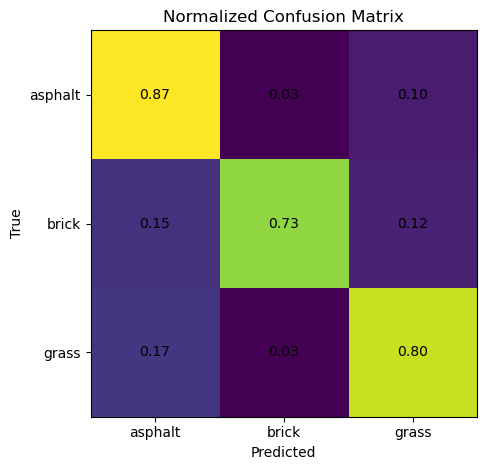

In [30]:
# matrix in % format random forestR
cm = confusion_matrix(y_test, pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure()
plt.imshow(cm_norm)

plt.title("Normalized Confusion Matrix")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "svm__C": [0.1, 1, 10, 50],
    "svm__gamma": ["scale", 0.01, 0.001]
}

grid = GridSearchCV(svm_model, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'svm__C': 50, 'svm__gamma': 0.01}


In [45]:
# SVM  (support vector machine) 

y = step_df["ground_type"]
X = step_df.drop(columns=["ground_type"]).fillna(0)

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=50, gamma=0.01))
])

svm_model.fit(X_train, y_train)
pred = svm_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred, target_names=le.classes_, digits=3))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 15 features:\n", importances.head(15))

Accuracy: 0.8275862068965517

Classification report:
               precision    recall  f1-score   support

     asphalt      0.765     0.839     0.800        31
       brick      0.800     0.769     0.784        26
       grass      0.929     0.867     0.897        30

    accuracy                          0.828        87
   macro avg      0.831     0.825     0.827        87
weighted avg      0.832     0.828     0.829        87


Confusion matrix:
 [[26  4  1]
 [ 5 20  1]
 [ 3  1 26]]

Top 15 features:
 accel_y_std            0.058042
pressure_01_max        0.045537
accel_y_max            0.034972
total_pressure_auc     0.034252
total_pressure_mean    0.033321
gyro_y_std             0.029953
pressure_04_max        0.027282
n_samples              0.024404
duration_s             0.023852
pressure_07_mean       0.023351
gyro_z_mean            0.022698
accel_x_mean           0.022349
total_pressure_max     0.021418
pressure_09_max        0.020463
gyro_y_max             0.020361
dtype: fl

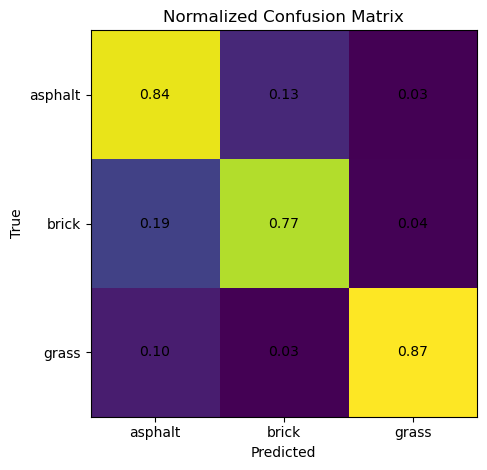

In [40]:
# matrix in % format 
cm = confusion_matrix(y_test, pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure()
plt.imshow(cm_norm)

plt.title("Normalized Confusion Matrix")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

# understandings